In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.datasets import load_iris
import tensorflow as tf
import seaborn as sns

In [ ]:
tf.get_logger().setLevel('ERROR')

In [ ]:
df = pd.read_csv("/content/student_depression_balanced.csv")

# Check if the target column exists in the custom data
# if TARGET_COLUMN_NAME not in df.columns:
#     raise ValueError(f"Target column '{TARGET_COLUMN_NAME}' not found in the custom dataset.")

# 1. Load and explore the dataset
print("# Data Exploration:")
print(f"Shape: {df.shape}")
print("\nTop 5 rows:")
print(df.head())
print("\nNull values (sum):")
print(df.isnull().sum())
print("\nDescriptive statistics:")
print(df.describe())

# Data Exploration:
Shape: (31734, 11)

Top 5 rows:
    Age      CGPA  Suicidal_Thoughts  Study_Hours  Family_History  \
0  0.60  0.792757                1.0     0.250000             0.0   
1  0.24  0.175050                0.0     0.250000             1.0   
2  0.52  0.402414                0.0     0.750000             1.0   
3  0.40  0.112676                1.0     0.333333             1.0   
4  0.28  0.623742                1.0     0.083333             0.0   

   Gender_Male  Gender_Female  Diet_Healthy  Diet_Moderate  Diet_Unhealthy  \
0          1.0            0.0           1.0            0.0             0.0   
1          0.0            1.0           0.0            1.0             0.0   
2          1.0            0.0           1.0            0.0             0.0   
3          0.0            1.0           0.0            1.0             0.0   
4          0.0            1.0           0.0            1.0             0.0   

   Depression  
0         1.0  
1         0.0  
2         0.0  


In [ ]:
# Identify classes
target_classes = df['Depression'].nunique()
print(f"\nNumber of classes in target column: {target_classes}")


Number of classes in target column: 2


In [ ]:
# Check balance
print("\nClass Distribution:")
print(df['Depression'].value_counts())
if df['Depression'].value_counts().std() < 5:
    print("Conclusion: The classes are balanced.")
else:
    print("Conclusion: The classes are imbalanced.")


Class Distribution:
Depression
1.0    15867
0.0    15867
Name: count, dtype: int64
Conclusion: The classes are balanced.


In [ ]:
# Separate features (X) and target (y)
X = df.drop('Depression', axis=1).values
y = df['Depression'].values

In [ ]:
# 2. Preprocessing: Scale numeric features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
X_scaled_df = pd.DataFrame(X_scaled, columns=df.drop('Depression', axis=1).columns)
print("\nScaled Data (First 5 rows):")
print(X_scaled_df.head())
print("\nScaled Data (Descriptive statistics - mean should be ~0, std dev ~1):")
print(X_scaled_df.describe().loc[['mean', 'std']])


Scaled Data (First 5 rows):
        Age      CGPA  Suicidal_Thoughts  Study_Hours  Family_History  \
0  1.431216  0.902104           0.840315    -1.072719       -0.960689   
1 -0.411929 -1.190566          -1.190030    -1.072719        1.040920   
2  1.021628 -0.420300          -1.190030     0.533751        1.040920   
3  0.407247 -1.401878           0.840315    -0.804974        1.040920   
4 -0.207135  0.329517           0.840315    -1.608209       -0.960689   

   Gender_Male  Gender_Female  Diet_Healthy  Diet_Moderate  Diet_Unhealthy  
0     0.889075      -0.889075      1.575040      -0.751270       -0.736269  
1    -1.124765       1.124765     -0.634905       1.331079       -0.736269  
2     0.889075      -0.889075      1.575040      -0.751270       -0.736269  
3    -1.124765       1.124765     -0.634905       1.331079       -0.736269  
4    -1.124765       1.124765     -0.634905       1.331079       -0.736269  

Scaled Data (Descriptive statistics - mean should be ~0, std dev ~1):

In [ ]:
# 3. Split dataset
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)


In [ ]:
# Perform one-hot encoding on y_train and y_test
y_train_ohe = to_categorical(y_train, num_classes=target_classes)
y_test_ohe = to_categorical(y_test, num_classes=target_classes)

In [ ]:
# Define input shape
INPUT_SHAPE = X_train.shape[1]

In [ ]:
# Build and Compile Initial ANN Model

def build_initial_model(input_shape, num_classes):
    model = Sequential([
        Dense(10, activation='relu', input_shape=(input_shape,), name='hidden_1'), # 1st Hidden Layer (10 nodes)
        Dense(5, activation='relu', name='hidden_2'), # 2nd Hidden Layer (5 nodes)
        Dense(num_classes, activation='softmax', name='output') # Output Layer (3 nodes)
    ], name='Model_1_Initial')

    # Compile the model
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

model_1 = build_initial_model(INPUT_SHAPE, target_classes)
print("\n--- Model 1 Summary (Initial) ---")
model_1.summary()

print("\n--- Training Model 1 (Initial) ---")
history_1 = model_1.fit(
    X_train, y_train_ohe,
    epochs=50,
    batch_size=10,
    validation_split=0.2, # 0.2 of X_train is used for validation
    verbose=0 # Set to 1 for live output
)


--- Model 1 Summary (Initial) ---


Model: "Model_1_Initial"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 5)              │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 2)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 177 (708.00 B)

 Trainable params: 177 (708.00 B)

 Non-trainable params: 0 (0.00 B)


--- Training Model 1 (Initial) ---


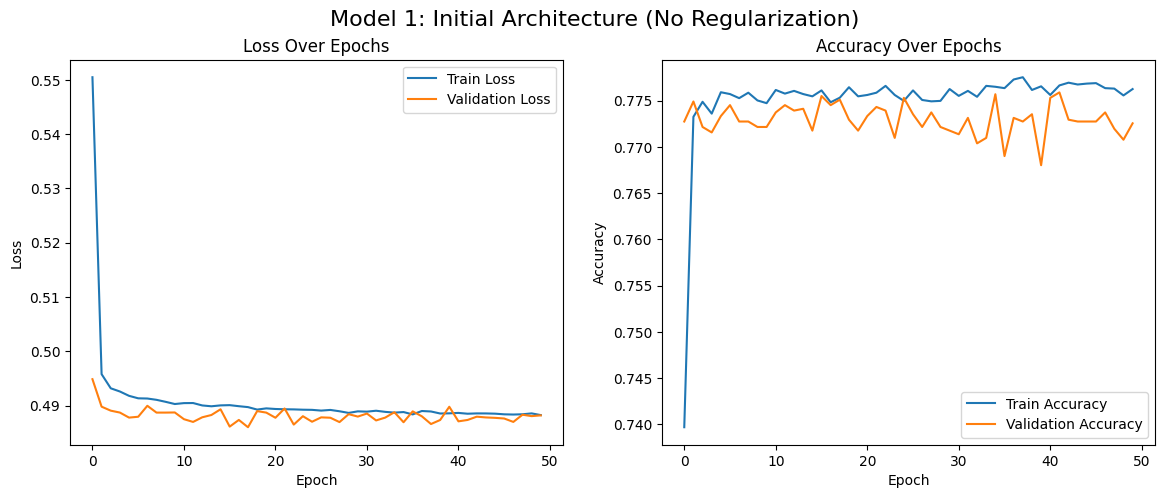

In [ ]:
# 7. Plot training vs validation curves
def plot_history(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=16)

    # Plot Loss
    ax1.plot(history.history['loss'], label='Train Loss')
    ax1.plot(history.history['val_loss'], label='Validation Loss')
    ax1.set_title('Loss Over Epochs')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()

    # Plot Accuracy
    ax2.plot(history.history['accuracy'], label='Train Accuracy')
    ax2.plot(history.history['val_accuracy'], label='Validation Accuracy')
    ax2.set_title('Accuracy Over Epochs')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    plt.show()

plot_history(history_1, "Model 1: Initial Architecture (No Regularization)")

In [ ]:
# 8. Evaluate on test data
print("\n--- Model 1: Evaluation on Test Data ---")
loss_1, acc_1 = model_1.evaluate(X_test, y_test_ohe, verbose=0)
print(f"Test Loss: {loss_1:.4f}")
print(f"Test Accuracy: {acc_1:.4f}")


--- Model 1: Evaluation on Test Data ---
Test Loss: 0.4852
Test Accuracy: 0.7810


In [ ]:
# Generate predictions and metrics
y_pred_ohe_1 = model_1.predict(X_test, verbose=0)
y_pred_1 = np.argmax(y_pred_ohe_1, axis=1)


Classification Report (Model 1):
              precision    recall  f1-score   support

         0.0       0.81      0.74      0.77      3174
         1.0       0.76      0.82      0.79      3173

    accuracy                           0.78      6347
   macro avg       0.78      0.78      0.78      6347
weighted avg       0.78      0.78      0.78      6347



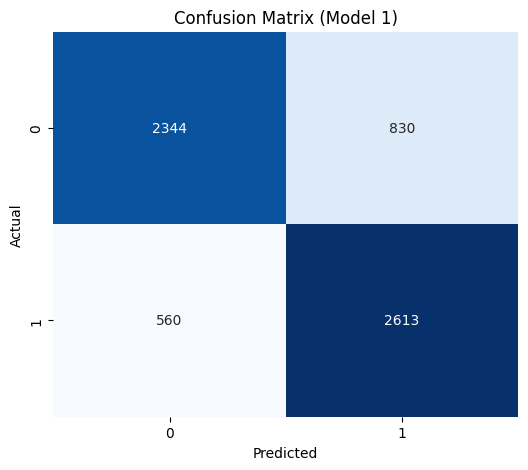

In [ ]:
print("\nClassification Report (Model 1):")
print(classification_report(y_test, y_pred_1))
cm_1 = confusion_matrix(y_test, y_pred_1)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_1, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix (Model 1)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


In [ ]:
# --- Step 6: Mitigating Overfitting (Model 2) ---

def build_tuned_model(input_shape, num_classes):
    model = Sequential([
        Dense(10, activation='relu', input_shape=(input_shape,), name='hidden_reduced'), # Reduced to 1 Hidden Layer
        Dropout(0.2, name='dropout'), # Added Dropout
        Dense(num_classes, activation='softmax', name='output_tuned')
    ], name='Model_2_Tuned')

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

model_2 = build_tuned_model(INPUT_SHAPE, target_classes)
print("\n--- Model 2 Summary (Reduced/Tuned) ---")
model_2.summary()


--- Model 2 Summary (Reduced/Tuned) ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Model_2_Tuned"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_reduced (Dense)          │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_tuned (Dense)            │ (None, 2)              │            22 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 132 (528.00 B)

 Trainable params: 132 (528.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Define Early Stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)


--- Training Model 2 (Tuned/Regularized with Early Stopping) ---
Epoch 10: early stopping
Restoring model weights from the end of the best epoch: 5.


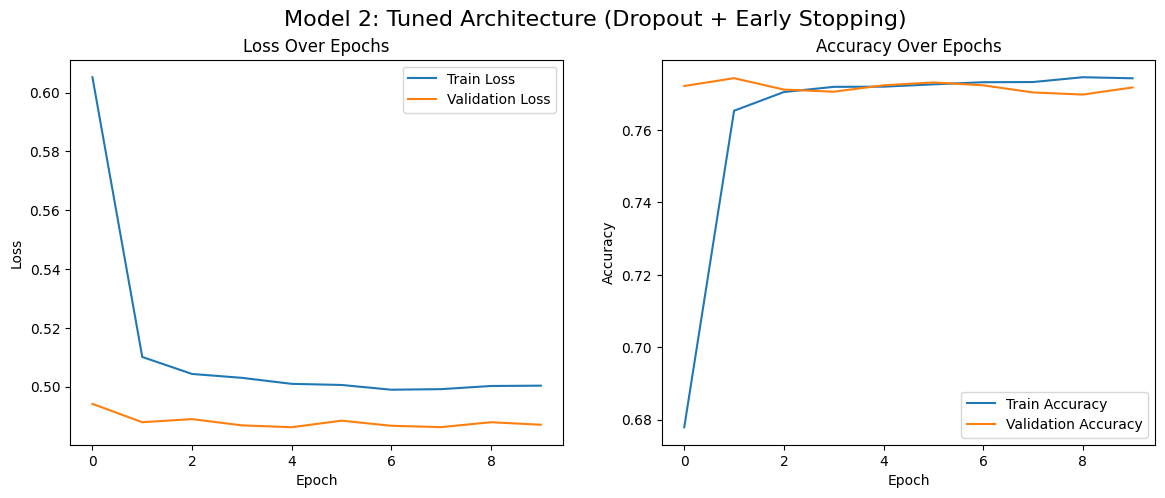

In [ ]:
print("\n--- Training Model 2 (Tuned/Regularized with Early Stopping) ---")
history_2 = model_2.fit(
    X_train, y_train_ohe,
    epochs=50,
    batch_size=10,
    validation_split=0.2,
    callbacks=[early_stopping], # Apply early stopping
    verbose=0 # Set to 1 for live output
)

# Plot history for Model 2
plot_history(history_2, "Model 2: Tuned Architecture (Dropout + Early Stopping)")

In [ ]:
# --- Step 5: Model Evaluation (Model 2) ---

print("\n--- Model 2: Evaluation on Test Data ---")
loss_2, acc_2 = model_2.evaluate(X_test, y_test_ohe, verbose=0)
print(f"Test Loss: {loss_2:.4f}")
print(f"Test Accuracy: {acc_2:.4f}")



--- Model 2: Evaluation on Test Data ---
Test Loss: 0.4843
Test Accuracy: 0.7816



Classification Report (Model 2):
              precision    recall  f1-score   support

         0.0       0.81      0.74      0.77      3174
         1.0       0.76      0.82      0.79      3173

    accuracy                           0.78      6347
   macro avg       0.78      0.78      0.78      6347
weighted avg       0.78      0.78      0.78      6347



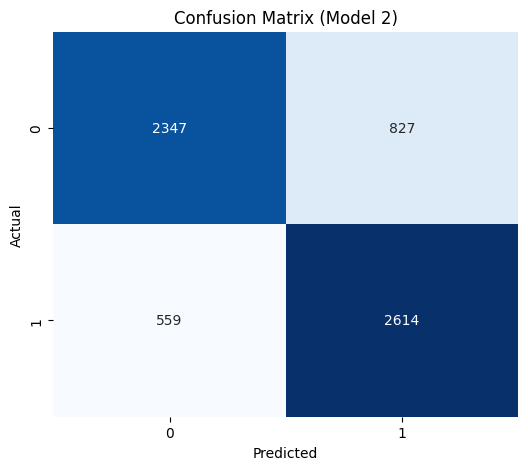

In [ ]:
# Generate predictions and metrics
y_pred_ohe_2 = model_2.predict(X_test, verbose=0)
y_pred_2 = np.argmax(y_pred_ohe_2, axis=1)

print("\nClassification Report (Model 2):")
print(classification_report(y_test, y_pred_2))
cm_2 = confusion_matrix(y_test, y_pred_2)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_2, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix (Model 2)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [ ]:
# 9. Stratified K-Fold Cross-Validation (Model 2 - Best Model)
k = 5
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
cv_metrics = {'accuracy': [], 'precision': [], 'recall': [], 'f1': []}

print("\n--- Stratified K-Fold Cross-Validation (k=5) on Model 2 ---")
fold_no = 1
for train_index, val_index in skf.split(X_scaled, y):
    X_train_cv, X_val_cv = X_scaled[train_index], X_scaled[val_index]
    y_train_cv_ohe = to_categorical(y[train_index], num_classes=target_classes)
    y_val_cv = y[val_index]
    y_val_cv_ohe = to_categorical(y_val_cv, num_classes=target_classes)
2


--- Stratified K-Fold Cross-Validation (k=5) on Model 2 ---


In [ ]:
    # Re-build a fresh model for each fold to prevent data leakage
model_cv = build_tuned_model(INPUT_SHAPE, target_classes)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
print(f"\n| Metric | Model 1 (Initial) - Test Set | Model 2 (Tuned) - Test Set | Model 2 (Tuned) - Avg K-Fold |".replace("$%.4f$", f"{acc_1:.4f}").replace("N/A", "-"))
print(f"| :--- | :---: | :---: | :---: |")
print(f"| **Test Accuracy** | {acc_1:.4f} | {acc_2:.4f} | {np.mean(cv_metrics['accuracy']):.4f} |")
print(f"| **Test Loss** | {loss_1:.4f} | {loss_2:.4f} | N/A |")


| Metric | Model 1 (Initial) - Test Set | Model 2 (Tuned) - Test Set | Model 2 (Tuned) - Avg K-Fold |
| :--- | :---: | :---: | :---: |
| **Test Accuracy** | 0.7810 | 0.7816 | nan |
| **Test Loss** | 0.4852 | 0.4843 | N/A |


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [ ]:

print("\n--- Step 7: Final Prediction Demonstration ---")

# 1. Define a new input sample.
# We will use the average features from the entire dataset as a neutral test case.
feature_names = df.drop('Depression', axis=1).columns.tolist()
if len(feature_names) > 0:
    # Get the mean of all original features
    average_sample = df.drop('Depression', axis=1).mean().values.reshape(1, -1)
    # Scale the new sample using the *fitted* scaler
    new_sample_scaled = scaler.transform(average_sample)

    # Predict probabilities (one-hot encoded output)
    probabilities = model_2.predict(new_sample_scaled, verbose=0)

    # Get the final predicted class index
    predicted_class_index = np.argmax(probabilities, axis=1)[0]

    # Create class labels for display
    class_labels = {i: f"Class {i}" for i in range(target_classes)}
    if 'Depression' == 'target': # If fallback to Iris
         class_labels = {0: 'Iris-setosa (0)', 1: 'Iris-versicolor (1)', 2: 'Iris-virginica (2)'}

    print(f"\nModel: {model_2.name} (Tuned/Best Performer)")
    print(f"Input Feature Names: {feature_names}")
    print(f"Input Sample (Original values - Average): {average_sample[0]}")
    print(f"Input Sample (Scaled values): {new_sample_scaled[0]}")

    # Display probability for each class
    print("\n--- Prediction Output ---")
    for i in range(target_classes):
        label = class_labels.get(i, f"Class {i}")
        # Assuming your 'depression' categories are mapped to 0, 1, 2, etc.
        print(f"Probability for {'Depression'} {label}: {probabilities[0][i]:.4f}")

    final_prediction_label = class_labels.get(predicted_class_index, f"Class {predicted_class_index}")
    print(f"\nFINAL PREDICTED CLASSIFICATION:")
    print(f"The model predicts the category of '{'Depression'}' is: {final_prediction_label}")

else:
    print("Could not demonstrate prediction: No features found in the dataset.")



--- Step 7: Final Prediction Demonstration ---

Model: Model_2_Tuned (Tuned/Best Performer)
Input Feature Names: ['Age', 'CGPA', 'Suicidal_Thoughts', 'Study_Hours', 'Family_History', 'Gender_Male', 'Gender_Female', 'Diet_Healthy', 'Diet_Moderate', 'Diet_Unhealthy']
Input Sample (Original values - Average): [0.32045732 0.52647696 0.58612214 0.58387454 0.4799584  0.55851768
 0.44148232 0.28729438 0.36078024 0.35152422]
Input Sample (Scaled values): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

--- Prediction Output ---
Probability for Depression Class 0: 0.5090
Probability for Depression Class 1: 0.4910

FINAL PREDICTED CLASSIFICATION:
The model predicts the category of 'Depression' is: Class 0
